In [2]:
#List of the specified values for each universe
kap_list = [0,0,0,1,-1]
O_M_list = [0.3, 1, 0, 2, 0.1]
O_L_list = [0.7, 0, 1, 0, 0]

Value of our own universe: 1.5426634133192976
Value for open, low density: 1.452449401746727


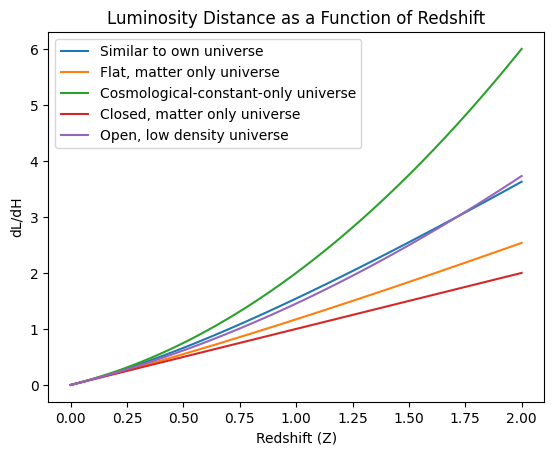

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from cosmology_functions import S_k

#Constants
C = 3 * 10**5
H_0 = 70
DH = C / H_0
#Define linspace of evenly spaced z's
z = np.linspace(0, 2, 10000)
#Define empty arrays to store dL/dH for each z value
C1 = []
C2 = []
C3 = []
C4 = []
C5 = []
#Loop over each z value to calculate dL
for zval in z:
    eval = 0
    eval_list = []
    #Loop over each value in the list, so you calc for each universe
    for j in range(0,5):
        O_M = O_M_list[j]
        O_L = O_L_list[j]
        O_k = 1 - O_M - O_L
        kap = kap_list[j]
        eval = (1+zval) * S_k(kap, O_M, O_L, zval, O_k, DH)
        eval_list.append(eval)
    #Add to an array for each scenario
    #For second part of problem - print out values for z = 1
    #C1 is our own universe, C5 is one closes to ours (open, low density)
    if(0.9998 < zval < 1.00000):
        print("Value of our own universe:", eval_list[0])
        ours = eval_list[0]
        print("Value for open, low density:", eval_list[4])
        other = eval_list[4]
    C1.append(eval_list[0])
    C2.append(eval_list[1])
    C3.append(eval_list[2])
    C4.append(eval_list[3])
    C5.append(eval_list[4])
#Plot each scenario
plt.plot(z,C1, label="Similar to own universe")
plt.plot(z,C2, label="Flat, matter only universe")
plt.plot(z,C3, label="Cosmological-constant-only universe")
plt.plot(z,C4, label="Closed, matter only universe")
plt.plot(z,C5, label="Open, low density universe")
plt.xlabel("Redshift (Z)")
plt.ylabel("dL/dH")
plt.title("Luminosity Distance as a Function of Redshift")
plt.legend()
plt.show()

In [13]:
#find error between the two values and print
#Since those values are stored anyway makes it easier
error = abs(other - ours) / ours
print(f"Fractional error to distinguish our universe from similar: {error:0.3g}")

Fractional error to distinguish our universe from similar: 0.0585


['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']


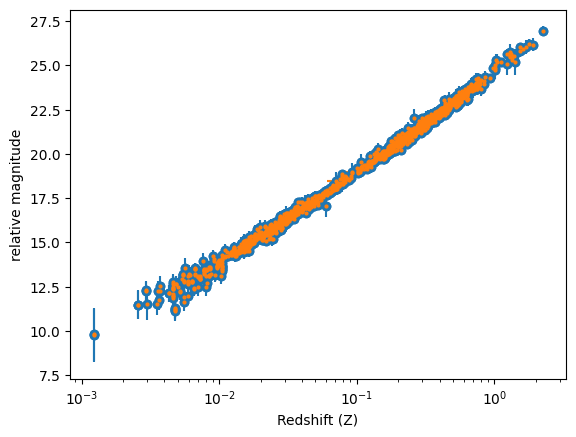

In [ ]:
import csv
filename = f"Pantheon+SH0ES.dat"
#with open(filename) as hdul:
# SNedat = hdul[0].data
#print(SNedat)
SNedat = []
with open(filename, 'r', newline='') as csvfile:
    csv_reader = csv.reader(csvfile, delimiter=' ')
    for row in csv_reader:
        SNedat.append(row)
#need to ignore header
#What might be easier is reading in data under each header to an array to then plot
print(SNedat[0])

zCMB = []
zCMBERR = []
m_b_corr = []
m_b_corr_err_DIAG = []

for row in SNedat[1:]: # Start from index 1 to skip header
    zCMB.append(float(row[4])) # 4th item (index 4)
    zCMBERR.append(float(row[5])) # 5th item (index 5)
    m_b_corr.append(float(row[8]))
    m_b_corr_err_DIAG.append(float(row[9]))
plt.scatter(zCMB, m_b_corr)
plt.xlabel("Redshift (Z)")
plt.ylabel("relative magnitude")
plt.errorbar(zCMB, m_b_corr, yerr = m_b_corr_err_DIAG, fmt='o',linestyle='none')
plt.errorbar(zCMB,m_b_corr, xerr = zCMBERR, markersize=2,fmt='o',linestyle='none')
plt.xscale('log')
plt.show()


In [ ]:
from cosmology_functions import chat
from cosmology_functions import f

##Second question set
O_M_list = [0.3, 1, 0, 2, 0.1]
O_L_list = [0.7, 0, 1, 0, 0]
#Can use any of the arrays just need the total length
#Also KEEP IN MIND using arrays created for problem 1
#store chi-square list
chisq_list = []
N = len(zCMB)

#Need to iterate over each uni list and produce chi square
for i in range(5):
    O_M = O_M_list[i]
    O_L = O_L_list[i]
    O_k = 1 - O_M - O_L
    #C-hat is a const, so calculate it before the loop
    Chat = chat(zCMB, m_b_corr, m_b_corr_err_DIAG, N, O_M, O_L, O_k)
    chisquare = 0
    #Make a loop to iterate over each value in the dataset
    for j in range(N):
        z = zCMB[j]
        #Just lay out the individual parts of the chi squared eq
        num = (m_b_corr[j] - f(z, O_M, O_L, O_k) - Chat)**2
        denom = (m_b_corr_err_DIAG[j])**2
        chisquare = chisquare + (num / denom)
    chisq_list.append(chisquare)
#Now print the individual values:
for i in range(5):
 print("Ωm =", O_M_list[i], " ΩΛ =", O_L_list[i], f" χ² = {chisq_list[i]:0.3g}")


Ωm = 0.3  ΩΛ = 0.7  χ² = 845
Ωm = 1  ΩΛ = 0  χ² = 1.43e+03
Ωm = 0  ΩΛ = 1  χ² = 1.56e+03
Ωm = 2  ΩΛ = 0  χ² = 2.44e+03
Ωm = 0.1  ΩΛ = 0  χ² = 859


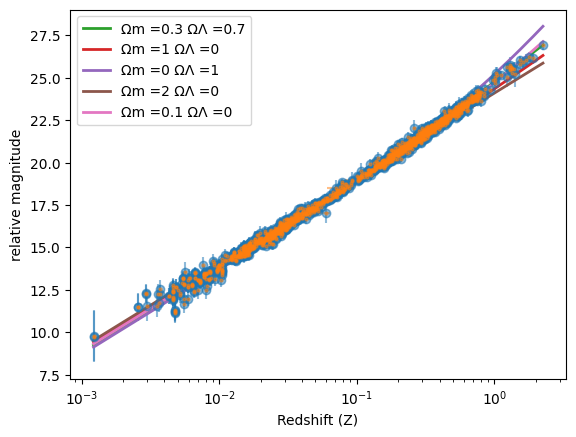

In [ ]:
plt.scatter(zCMB, m_b_corr,alpha=0.1)
plt.errorbar(zCMB, m_b_corr, yerr = m_b_corr_err_DIAG, fmt='o',linestyle='none',alpha = 0.5)
plt.errorbar(zCMB,m_b_corr, xerr = zCMBERR, markersize=2,fmt='o',linestyle='none',alpha = 0.5)
N = len(zCMB)
for i in range(5):
    O_M = O_M_list[i]
    O_L = O_L_list[i]
    O_k = 1 - O_M - O_L
    relmag = []
    Chat = chat(zCMB, m_b_corr, m_b_corr_err_DIAG, N, O_M, O_L, O_k)
    for j in range(N):
        z = zCMB[j]
        #want specifically f and Chat here (thas the relative mag expectation)  
        # #Adding them cause subtraction is for the chi square calc
        m_rel = f(z, O_M, O_L, O_k) + Chat
        #Make a list of all the simulated relative magnitudes
        #then you'll plot for each lin ig
        relmag.append(m_rel)
    plt.plot(zCMB, relmag, linewidth=2, label=f"Ωm ={O_M_list[i]} ΩΛ ={O_L_list[i]}")
plt.xscale('log')
plt.xlabel("Redshift (Z)")
plt.ylabel("relative magnitude")
plt.legend()
plt.show()

/home/pengu/code/assigment_code/Cosmology/cosmology_functions.py:12: RuntimeWarning: invalid value encountered in sqrt
  return (O_M*(1+z)**3 + O_L + O_k*(1+z)**2)**0.5
/home/pengu/code/assigment_code/Cosmology/cosmology_functions.py:103: RuntimeWarning: invalid value encountered in log10
  return 5*np.log10(dL)


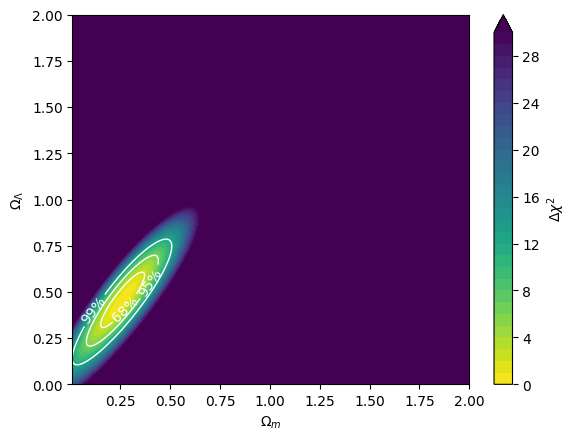

376 grid points within 1σ
Ωm range in 1σ: 0.158 - 0.369
ΩΛ range in 1σ: 0.315 - 0.606
Best Ωm and ΩΛ: Ωm = 0.26, ΩΛ = 0.457, chisq = 824


In [ ]:
from cosmology_functions import chisq_vec
from matplotlib.colors import LogNorm

#Contour plot using chi-square approx.:
zCMB_arr = np.asarray(zCMB)
m_b_corr_arr = np.asarray(m_b_corr)
m_b_corr_err_arr = np.asarray(m_b_corr_err_DIAG)


O_M_fake = np.linspace(0.01, 2, 256)
O_L_fake = np.linspace(0.0, 2, 255)
# Create the chi-square grid for each O_M and O_L value
chi2s = np.zeros((len(O_M_fake), len(O_L_fake)))
#Iterate over each value to calculate at each point???
#FIX - previous runs were computing manually - causing 200 million direct integrations
#this should reduce it to 65,000 integrations, slices are calculated at once

for i, O_M in enumerate(O_M_fake):
    for j, O_L in enumerate(O_L_fake):
        O_k = 1 - O_M - O_L
        try:
            #C-hat is a const, so calculate it before the loop
            #integration must be performed such that it adds onto the previous value
            
            chi2s[i, j] = chisq_vec(zCMB_arr, m_b_corr_arr, m_b_corr_err_arr,
                                        O_M, O_L, O_k)

            if not np.isfinite(chi2s[i,j]):
                chi2s[i, j] = np.inf
        except Exception:
            chi2s[i, j] = np.inf
# Regularize infinities
chi2s[chi2s == np.inf] = 5000.0 
# Plot
chi2_min = np.min(chi2s)
delta_chi2 = chi2s - chi2_min

levels = [2.30, 6.18, 11.83]

fig, ax = plt.subplots()
filled = ax.contourf(O_M_fake, O_L_fake, delta_chi2.T,
                      levels=np.linspace(0, 30, 31), extend='max', cmap='viridis_r')
lines = ax.contour(O_M_fake, O_L_fake, delta_chi2.T,
                    levels= levels, colors='white', linewidths=1)
ax.clabel(lines, fmt={2.30: '68%', 6.18: '95%', 11.83: '99%'})
plt.colorbar(filled, label=r'$\Delta\chi^2$')
plt.xlabel(r'$\Omega_m$')
plt.ylabel(r'$\Omega_\Lambda$')
plt.show()

mask = delta_chi2 < 2.30
i_idx, j_idx = np.where(mask)
S_val_1 = np.column_stack([O_M_fake[i_idx], O_L_fake[j_idx], chi2s[i_idx, j_idx]])

print(f"{len(S_val_1)} grid points within 1σ")
print(f"Ωm range in 1σ: {S_val_1[:,0].min():0.3g} - {S_val_1[:,0].max():0.3g}")
print(f"ΩΛ range in 1σ: {S_val_1[:,1].min():0.3g} - {S_val_1[:,1].max():0.3g}")

best_idx = np.argmin(S_val_1[:, 2])
print(f"Best Ωm and ΩΛ: Ωm = {S_val_1[best_idx, 0]:0.3g}, ΩΛ = {S_val_1[best_idx, 1]:0.3g}, chisq = {(S_val_1[best_idx, 2]):0.3g}")

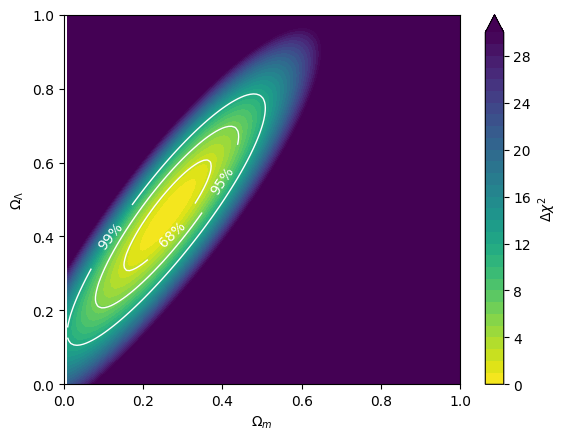

In [22]:
levels = [2.30, 6.18, 11.83]

fig, ax = plt.subplots()
filled = ax.contourf(O_M_fake, O_L_fake, delta_chi2.T,
                      levels=np.linspace(0, 30, 31), extend='max', cmap='viridis_r')
lines = ax.contour(O_M_fake, O_L_fake, delta_chi2.T,
                    levels= levels, colors='white', linewidths=1)
ax.clabel(lines, fmt={2.30: '68%', 6.18: '95%', 11.83: '99%'})
plt.colorbar(filled, label=r'$\Delta\chi^2$')
plt.xlim(0,1.00)
plt.ylim(0,1.00)
plt.xlabel(r'$\Omega_m$')
plt.ylabel(r'$\Omega_\Lambda$')
plt.show()

In [ ]:
#bug test:
from cosmology_functions import comoving_distance_interp
from cosmology_functions import f_vec

O_M = 0.3
O_L = 0.7
O_k = 1 - O_M - O_L
test = [x for x in zCMB if x > 1]
print(len(test))
print(len(zCMB))
Chat = chat(zCMB, m_b_corr, m_b_corr_err_DIAG, N, O_M, O_L, O_k)
dc = comoving_distance_interp(zCMB_arr, O_M, O_L, O_k)
f_vals = f_vec(zCMB_arr, O_M, O_L, O_k, dc)
w = 1.0 / m_b_corr_err_arr**2
C_vec = np.sum(w * (m_b_corr_arr - f_vals)) / np.sum(w)

print("Chat (original):", Chat)
print("C (vectorized): ", C_vec)
print("difference:     ", Chat - C_vec)

#note that there is negligible difference between the two methods.


25
1701
Chat (original): 23.806744316644583
C (vectorized):  23.80674626935147
difference:      -1.9527068886304733e-06
845.2196862952641
21.62076851783104
vs original function finding 0.111


In [ ]:
#another test to show that the two chi square computations produce numerically similar results
O_M_test, O_L_test = 0.158, 0.315
O_k_test = 1 - O_M_test - O_L_test

Chat_test = chat(zCMB, m_b_corr, m_b_corr_err_DIAG, N, O_M_test, O_L_test, O_k_test)

chisq_loop = 0
for j in range(N):
    z = zCMB[j]
    num = (m_b_corr[j] - f(z, O_M_test, O_L_test, O_k_test) - Chat_test)**2
    denom = m_b_corr_err_DIAG[j]**2
    chisq_loop += num / denom

chisq_vec_val = chisq_vec(zCMB_arr, m_b_corr_arr, m_b_corr_err_arr, O_M_test, O_L_test, O_k_test)

print("loop:", chisq_loop)
print("vec: ", chisq_vec_val)

loop: 825.7679621142909
vec:  825.7691249976896
